In [51]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix


In [52]:
BASE_DIR = "/content/dataset/MY_data"
TRAIN_DIR = BASE_DIR + "/train"
TEST_DIR = BASE_DIR + "/test"
PRED_DIR = BASE_DIR + "/predict"

print("Train:", TRAIN_DIR)
print("Test:", TEST_DIR)
print("Predict:", PRED_DIR)


Train: /content/dataset/MY_data/train
Test: /content/dataset/MY_data/test
Predict: /content/dataset/MY_data/predict


In [53]:
class_names = sorted(os.listdir(TRAIN_DIR))
class_names


['Apple',
 'Banana',
 'avocado',
 'cherry',
 'kiwi',
 'mango',
 'orange',
 'pinenapple',
 'strawberries',
 'watermelon']

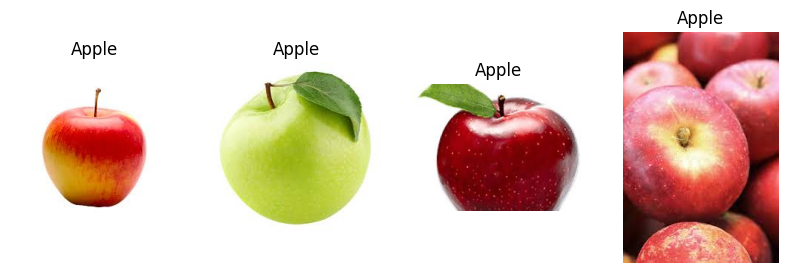

In [54]:
def show_examples(folder, n=4):
    files = os.listdir(os.path.join(folder, class_names[0]))[:n]
    plt.figure(figsize=(10,3))
    for i,f in enumerate(files):
        img = plt.imread(os.path.join(folder, class_names[0], f))
        plt.subplot(1,n,i+1)
        plt.imshow(img)
        plt.title(class_names[0])
        plt.axis("off")
    plt.show()

show_examples(TRAIN_DIR)


In [55]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1/255.0,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(
    rescale=1/255.0,
    validation_split=0.2
)

train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_data = val_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

test_data = ImageDataGenerator(rescale=1/255.0).flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


Found 1841 images belonging to 10 classes.
Found 460 images belonging to 10 classes.
Found 1025 images belonging to 10 classes.


In [56]:
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
output = Dense(len(class_names), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [57]:
history1 = model.fit(
    train_data,
    epochs=8,
    validation_data=val_data,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.3524 - loss: 1.9725 - val_accuracy: 0.8326 - val_loss: 0.6076
Epoch 2/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.7995 - loss: 0.6331 - val_accuracy: 0.8804 - val_loss: 0.3984
Epoch 3/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.8607 - loss: 0.4416 - val_accuracy: 0.8913 - val_loss: 0.3395
Epoch 4/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.8886 - loss: 0.3812 - val_accuracy: 0.9000 - val_loss: 0.2964
Epoch 5/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.8947 - loss: 0.3234 - val_accuracy: 0.9174 - val_loss: 0.2732
Epoch 6/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.9050 - loss: 0.2839 - val_accuracy: 0.9196 - val_loss: 0.2435
Epoch 7/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.9243 - loss: 0.2605 - val_accuracy: 0.9130 - val_loss: 0.2598
Epoch 8/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.9231 - loss: 0.2423 - val_accuracy: 0.9261 - val_loss:

In [58]:
for layer in base_model.layers[-40:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_data,
    epochs=8,
    validation_data=val_data,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
)


Epoch 1/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.7662 - loss: 0.7062 - val_accuracy: 0.9304 - val_loss: 0.2334
Epoch 2/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.8473 - loss: 0.5052 - val_accuracy: 0.9239 - val_loss: 0.2538
Epoch 3/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.8706 - loss: 0.3931 - val_accuracy: 0.9196 - val_loss: 0.2615
Epoch 4/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.8808 - loss: 0.3629 - val_accuracy: 0.9196 - val_loss: 0.2628


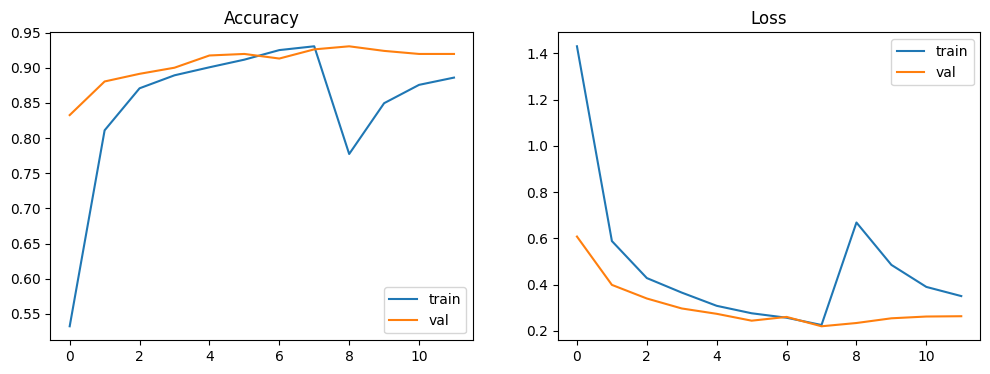

In [59]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history1.history['accuracy'] + history2.history['accuracy'])
plt.plot(history1.history['val_accuracy'] + history2.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(['train','val'])


plt.subplot(1,2,2)
plt.plot(history1.history['loss'] + history2.history['loss'])
plt.plot(history1.history['val_loss'] + history2.history['val_loss'])
plt.title("Loss")
plt.legend(['train','val'])

plt.show()


In [60]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)


33/33 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.5593 - loss: 2.5450
Test Accuracy: 0.6936585307121277
Test Loss: 1.6690407991409302


In [61]:
test_data.reset()
pred_probs = model.predict(test_data)
pred_classes = np.argmax(pred_probs, axis=1)

true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

print(classification_report(true_classes, pred_classes, target_names=class_labels))
print(confusion_matrix(true_classes, pred_classes))


33/33 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step
              precision    recall  f1-score   support

       apple       0.80      0.83      0.81        89
     avocado       0.01      0.01      0.01       105
      banana       0.00      0.00      0.00       106
      cherry       0.86      0.79      0.83       105
        kiwi       0.94      0.91      0.93       105
       mango       0.74      0.86      0.79       105
      orange       0.86      0.89      0.87        97
  pinenapple       0.99      0.95      0.97       105
 stawberries       0.86      0.86      0.86       103
  watermelon       0.88      0.88      0.88       105

    accuracy                           0.69      1025
   macro avg       0.69      0.70      0.70      1025
weighted avg       0.69      0.69      0.69      1025

[[ 74   0   1   5   1   4   1   0   1   2]
 [  1   1  93   1   0   8   0   0   1   0]
 [  0  96   0   0   1   7   2   0   0   0]
 [ 14   0   0  83   0   0   1   0   4   3]
 [  0   1   1   0  96   3   2 

In [62]:
from google.colab import files
uploaded = files.upload()


Saving img_111.jpeg to img_111 (1).jpeg


In [63]:
from tensorflow.keras.preprocessing import image

fname = list(uploaded.keys())[0]
img = image.load_img(fname, target_size=IMG_SIZE)

img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)
pred_class = np.argmax(pred)

idx_to_class = {v:k for k,v in train_data.class_indices.items()}
print("Predicted class =", idx_to_class[pred_class])


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted class = watermelon


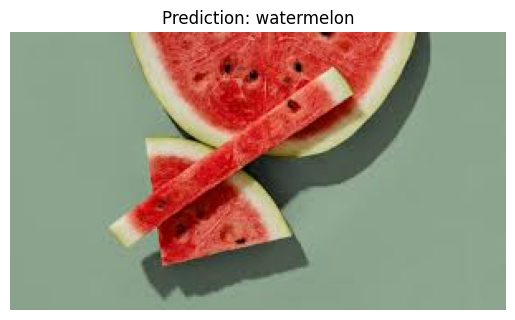

In [64]:
plt.imshow(image.load_img(fname))
plt.title("Prediction: " + idx_to_class[pred_class])
plt.axis("off")
plt.show()


In [65]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)


33/33 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.5593 - loss: 2.5450
Test Accuracy: 0.6936585307121277
Test Loss: 1.6690407991409302
